
Collapses the 85 JP POI categories into the 11 shared Massive STEPs top-level categories,
then re-runs LDA on the aligned matrix so zone topics are interpretable and transferable.

In [5]:
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation

# 1. Hard-coded alignment table
# Format: (cat_id_1indexed, hm_category_name, steps_category)

ALIGNMENT = [
    (1,  'Food',                       'Dining and Drinking'),
    (2,  'Shopping',                    'Retail'),
    (3,  'Entertainment',               'Arts and Entertainment'),
    (4,  'Japanese restaurant',         'Dining and Drinking'),
    (5,  'Western restaurant',          'Dining and Drinking'),
    (6,  'Eat all you can restaurant',  'Dining and Drinking'),
    (7,  'Chinese restaurant',          'Dining and Drinking'),
    (8,  'Indian restaurant',           'Dining and Drinking'),
    (9,  'Ramen restaurant',            'Dining and Drinking'),
    (10, 'Curry restaurant',            'Dining and Drinking'),
    (11, 'BBQ restaurant',              'Dining and Drinking'),
    (12, 'Hot pot restaurant',          'Dining and Drinking'),
    (13, 'Bar',                         'Nightlife Spot'),
    (14, 'Diner',                       'Dining and Drinking'),
    (15, 'Creative cuisine',            'Dining and Drinking'),
    (16, 'Organic cuisine',             'Dining and Drinking'),
    (17, 'Pizza',                       'Dining and Drinking'),
    (18, 'Café',                        'Dining and Drinking'),
    (19, 'Tea Salon',                   'Dining and Drinking'),
    (20, 'Bakery',                      'Dining and Drinking'),
    (21, 'Sweets',                      'Dining and Drinking'),
    (22, 'Wine Bar',                    'Nightlife Spot'),
    (23, 'Pub',                         'Nightlife Spot'),
    (24, 'Disco',                       'Nightlife Spot'),
    (25, 'Beer Garden',                 'Nightlife Spot'),
    (26, 'Fast Food',                   'Dining and Drinking'),
    (27, 'Karaoke',                     'Nightlife Spot'),
    (28, 'Cruising',                    'Nightlife Spot'),
    (29, 'Theme Park Restaurant',       'Arts and Entertainment'),
    (30, 'Amusement Restaurant',        'Arts and Entertainment'),
    (31, 'Other Restaurants',           'Dining and Drinking'),
    (32, 'Glasses',                     'Retail'),
    (33, 'Drug Store',                  'Retail'),
    (34, 'Electronics Store',           'Retail'),
    (35, 'DIY Store',                   'Retail'),
    (36, 'Convenience Store',           'Retail'),
    (37, 'Recycle Shop',                'Retail'),
    (38, 'Interior Shop',               'Retail'),
    (39, 'Sports Store',                'Retail'),
    (40, 'Clothes Store',               'Retail'),
    (41, 'Grocery Store',               'Retail'),
    (42, 'Online Grocery Store',        'Retail'),
    (43, 'Sports Recreation',           'Sports and Recreation'),
    (44, 'Game Arcade',                 'Arts and Entertainment'),
    (45, 'Swimming Pool',               'Sports and Recreation'),
    (46, 'Hotel',                       'Travel and Transportation'),
    (47, 'Park',                        'Landmarks and Outdoors'),
    (48, 'Transit Station',             'Travel and Transportation'),
    (49, 'Parking Area',                'Travel and Transportation'),
    (50, 'Casino',                      'Nightlife Spot'),
    (51, 'Hospital',                    'Health and Medicine'),
    (52, 'Pharmacy',                    'Health and Medicine'),
    (53, 'Chiropractic',                'Health and Medicine'),
    (54, 'Elderly Care Home',           'Health and Medicine'),
    (55, 'Fishing',                     'Sports and Recreation'),
    (56, 'School',                      'Community and Government'),
    (57, 'Cram School',                 'Community and Government'),
    (58, 'Kindergarten',                'Community and Government'),
    (59, 'Real Estate',                 'Business and Professional Services'),
    (60, 'Home Appliances',             'Retail'),
    (61, 'Post Office',                 'Community and Government'),
    (62, 'Laundry',                     'Business and Professional Services'),
    (63, 'Driving School',              'Community and Government'),
    (64, 'Wedding Ceremony',            'Arts and Entertainment'),
    (65, 'Cemetary',                    'Community and Government'),
    (66, 'Bank',                        'Business and Professional Services'),
    (67, 'Vet',                         'Health and Medicine'),
    (68, 'Hot Spring',                  'Landmarks and Outdoors'),
    (69, 'Hair Salon',                  'Business and Professional Services'),
    (70, 'Lawyer Office',               'Business and Professional Services'),
    (71, 'Recruitment Office',          'Business and Professional Services'),
    (72, 'City Hall',                   'Community and Government'),
    (73, 'Community Center',            'Community and Government'),
    (74, 'Church',                      'Community and Government'),
    (75, 'Retail Store',                'Retail'),
    (76, 'Accountant Office',           'Business and Professional Services'),
    (77, 'IT Office',                   'Business and Professional Services'),
    (78, 'Publisher Office',            'Business and Professional Services'),
    (79, 'Building Material',           'Business and Professional Services'),
    (80, 'Gardening',                   'Retail'),
    (81, 'Heavy Industry',              'Business and Professional Services'),
    (82, 'NPO',                         'Community and Government'),
    (83, 'Utility Copany',              'Business and Professional Services'),
    (84, 'Port',                        'Travel and Transportation'),
    (85, 'Research Facility',           'Business and Professional Services'),
]

STEPS_CATEGORIES = [
    'Arts and Entertainment',
    'Business and Professional Services',
    'Community and Government',
    'Dining and Drinking',
    'Health and Medicine',
    'Event',
    'Landmarks and Outdoors',
    'Nightlife Spot',
    'Retail',
    'Sports and Recreation',
    'Travel and Transportation',
]

mapping_df = pd.DataFrame(ALIGNMENT, columns=['cat_id', 'hm_category', 'steps_category'])

print('HM categories per STEPs bucket:')
print(mapping_df['steps_category'].value_counts().to_string())

HM categories per STEPs bucket:
steps_category
Dining and Drinking                   20
Retail                                15
Business and Professional Services    13
Community and Government              10
Nightlife Spot                         8
Arts and Entertainment                 5
Health and Medicine                    5
Travel and Transportation              4
Sports and Recreation                  3
Landmarks and Outdoors                 2


In [6]:
import os

poi_matrix = np.zeros((40000, 85), dtype=np.float32)
directory = "cell_POIcat.csv"

for filename in os.listdir(directory):
    parts = filename.split(',')
    if len(parts) != 4:
        continue
    try:
        x, y, cat_id, count = map(int, parts)
        grid_idx = (x - 1) * 200 + (y - 1)
        poi_matrix[grid_idx, cat_id - 1] = count
    except ValueError:
        continue

poi_df = pd.DataFrame(poi_matrix)
print(f"Non-zero cells: {(poi_matrix.sum(axis=1) > 0).sum():,} / 40,000")

Non-zero cells: 20,146 / 40,000


In [7]:
# ── 2. Build the aligned 10-column matrix from poi_matrix


aligned_matrix = np.zeros((poi_matrix.shape[0], len(STEPS_CATEGORIES)), dtype=np.float32)

for col_idx, steps_cat in enumerate(STEPS_CATEGORIES):
    cat_ids = mapping_df.loc[mapping_df['steps_category'] == steps_cat, 'cat_id'].tolist()
    raw_cols = [cid - 1 for cid in cat_ids]   # convert to 0-indexed
    aligned_matrix[:, col_idx] = poi_matrix[:, raw_cols].sum(axis=1)

aligned_df = pd.DataFrame(aligned_matrix, columns=STEPS_CATEGORIES)

# Sanity check: total count must be preserved
assert abs(poi_matrix.sum() - aligned_matrix.sum()) < 1.0, 'Count mismatch — check mapping'

print(f'Aligned matrix shape: {aligned_df.shape}')
print(f'Non-zero cells: {(aligned_matrix.sum(axis=1) > 0).sum():,} / {poi_matrix.shape[0]:,}')
print('\nTotal POI counts per STEPs category:')
print(aligned_df.sum().sort_values(ascending=False).apply(lambda x: f'{x:,.0f}').to_string())

Aligned matrix shape: (40000, 11)
Non-zero cells: 20,146 / 40,000

Total POI counts per STEPs category:
Business and Professional Services    186,146
Retail                                 76,191
Community and Government               68,465
Dining and Drinking                    53,539
Travel and Transportation              36,656
Health and Medicine                    35,521
Sports and Recreation                  14,007
Nightlife Spot                         11,873
Landmarks and Outdoors                 11,692
Arts and Entertainment                  1,081
Event                                       0


Active (non-empty) cells: 20,146
Computing UMass coherence for k = 2 3 4 5 6 7 8 9 10 11 12 
Done.


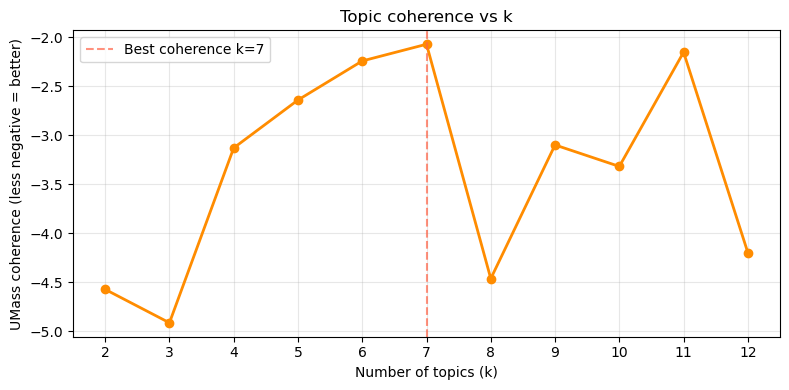

Saved: topic_selection_coherence.png
Best coherence k = 7 (score: -2.0707)


In [11]:
# ── Cell 2: Coherence sweep (gensim UMass) ────────────────────────────────────
# UMass coherence measures how often the top-N categories of a topic

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


active_mask = aligned_df.drop(columns='grid_id', errors='ignore').sum(axis=1) > 0
X = aligned_df.drop(columns='grid_id', errors='ignore')[active_mask].values.astype(np.float32)
print(f"Active (non-empty) cells: {X.shape[0]:,}")
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

K_RANGE = range(2, 13) # test k=2 to 12 topics
fitted_models = {} 

try:
    import gensim
    from gensim.models.coherencemodel import CoherenceModel
    from gensim import corpora
    GENSIM_AVAILABLE = True
except ImportError:
    GENSIM_AVAILABLE = False
    print("gensim not available — skipping coherence sweep")

if GENSIM_AVAILABLE:
    STEPS_CATEGORIES = list(aligned_df.drop(columns='grid_id', errors='ignore').columns)
    TOP_N = 5   # top N categories per topic used for coherence

    # Build a gensim corpus from the aligned matrix
    id2word = corpora.Dictionary([STEPS_CATEGORIES])
    corpus = [
        [(cat_idx, int(count)) for cat_idx, count in enumerate(row) if count > 0]
        for row in X_train
    ]

    coherence_scores = []
    print("Computing UMass coherence for k = ", end="")

    for k in K_RANGE:
        print(k, end=" ", flush=True)
        lda_k = LatentDirichletAllocation(
            n_components=k,
            random_state=42,
            learning_method='batch',
            max_iter=20
        )
        lda_k.fit(X_train)
        fitted_models[k] = lda_k

        topics_top_n = [
            [STEPS_CATEGORIES[i] for i in topic.argsort()[:-(TOP_N + 1):-1]]
            for topic in lda_k.components_
        ]

        cm = CoherenceModel(
            topics=topics_top_n,
            corpus=corpus,
            dictionary=id2word,
            coherence='u_mass'
        )
        coherence_scores.append(cm.get_coherence())

    print("\nDone.")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(list(K_RANGE), coherence_scores, marker='o', linewidth=2, color='darkorange')
    ax.set_xlabel('Number of topics (k)')
    ax.set_ylabel('UMass coherence (less negative = better)')
    ax.set_title('Topic coherence vs k')
    ax.set_xticks(list(K_RANGE))
    ax.grid(True, alpha=0.3)

    # Mark the best coherence k
    best_coherence_k = list(K_RANGE)[np.argmax(coherence_scores)]
    ax.axvline(best_coherence_k, color='tomato', linestyle='--', alpha=0.7,
               label=f'Best coherence k={best_coherence_k}')
    ax.legend()

    plt.tight_layout()

    plt.show()
    print(f"Saved: topic_selection_coherence.png")
    print(f"Best coherence k = {best_coherence_k} (score: {coherence_scores[best_coherence_k - 2]:.4f})")

In [12]:
# 3. Run LDA on the aligned matrix with the selected number of topics

N_TOPICS = 7

lda_aligned = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method='batch',
    max_iter=20
)
zone_distributions = lda_aligned.fit_transform(aligned_df)

zone_cols = [f'zone_{i}_prob' for i in range(N_TOPICS)]
dist_df = pd.DataFrame(zone_distributions, columns=zone_cols)
dist_df['grid_id'] = range(len(dist_df))
dist_df['dominant_zone'] = zone_distributions.argmax(axis=1)

print('LDA embedding shape:', dist_df.shape)
print('\nTopic profiles (now with interpretable STEPs names):')
print('=' * 60)
for topic_idx, weights in enumerate(lda_aligned.components_):
    norm = weights / weights.sum()
    top3 = sorted(zip(STEPS_CATEGORIES, norm), key=lambda x: -x[1])[:3]
    dominant = top3[0][0]
    print(f'\nZone {topic_idx} — dominant: {dominant}')
    for cat, w in top3:
        print(f'  {w:.1%}  {cat}')

LDA embedding shape: (40000, 9)

Topic profiles (now with interpretable STEPs names):

Zone 0 — dominant: Health and Medicine
  68.3%  Health and Medicine
  8.9%  Community and Government
  8.3%  Business and Professional Services

Zone 1 — dominant: Business and Professional Services
  46.1%  Business and Professional Services
  20.8%  Landmarks and Outdoors
  12.2%  Sports and Recreation

Zone 2 — dominant: Community and Government
  90.7%  Community and Government
  6.6%  Business and Professional Services
  1.0%  Landmarks and Outdoors

Zone 3 — dominant: Retail
  64.6%  Retail
  17.7%  Business and Professional Services
  7.8%  Community and Government

Zone 4 — dominant: Business and Professional Services
  60.9%  Business and Professional Services
  13.4%  Retail
  9.6%  Community and Government

Zone 5 — dominant: Travel and Transportation
  89.7%  Travel and Transportation
  3.4%  Landmarks and Outdoors
  2.4%  Sports and Recreation

Zone 6 — dominant: Dining and Drinking
  44

In [ ]:
# # ── 4. Save outputs ───────────────────────────────────────────────────────────

# # The LDA embedding (zone distributions) — input to LLM projection step
# dist_df.to_parquet('grid_lda_embeddings.parquet', index=False)
# print('Saved: grid_lda_embeddings.parquet')
# print('  Columns:', dist_df.columns.tolist())
# print('  Shape:  ', dist_df.shape)

# # The aligned POI counts — useful for replicating on Massive STEPs data
# aligned_df['grid_id'] = range(len(aligned_df))
# aligned_df.to_parquet('grid_aligned_poi.parquet', index=False)
# print('\nSaved: grid_aligned_poi.parquet')

# # The mapping table — needed to transform any new dataset before calling lda.transform()
# mapping_df.to_csv('cat_alignment_output.csv', index=False)
# print('Saved: cat_alignment_output.csv')

# print('\nTo apply this LDA to Massive STEPs data:')
# print('  1. Aggregate your STEPs POI counts into the same 10 column order as STEPS_CATEGORIES')
# print('  2. Call: new_embeddings = lda_aligned.transform(new_aligned_df)')
# print('  3. new_embeddings has shape (n_cells, 5) — same embedding space')